# Damped Harmonic Oscillator

Load all necessary libraries

In [1]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 1. Problem Background

In classical mechanics, a harmonic oscillator is a system that, when displaced from its equilibrium position, experiences a restoring force $F$ proportional to the displacement $x$: $\vec{F}=-k\vec{x}$, where k is a positive constant.




If a frictional force (damping) proportional to the velocity is present, the harmonic oscillator is described as a damped oscillator. If an external time-dependent force is present, the harmonic oscillator is described as a driven oscillator.




A simple harmonic oscillator is an oscillator that is neither driven nor damped. Assume it consists of a mass $m$, we can use a simple ordinary differential equation to describe its replacement in terms of time:
$$F=m\frac{d^2x}{dt^2}=-kx \implies x(t) =A\sin(\omega t+\phi) $$




However, in the real world, friction (or damping) commonly slows the motion of the system. The frictional force $F_f$ can be modeled as being proportional to the velocity of the object and in a direction opposes the direction of the motion of the object: $F_f=-cv$, where $c$ is called the viscous damping coefficient. Therefore, the damped oscillator can be described using the following ODE:
$$F=m\frac{d^2x}{dt^2}=-kx-c\frac{dx}{dt}\implies\frac{d^2 x}{dt^2}+2\xi \omega \frac{dx}{dt}+ \omega^2 x=0$$
where $\xi$ is called the damping ratio of this damped harmonic oscillator. The solutions of this type of ODE are generally classified based on the discriminant of its corresponding characteristic equation: $r^2+2\xi \omega r+ \omega^2=0 \implies \Delta = 4\omega^2(\xi ^2-1)$. The value of the damping ratio $\xi$ critically determines the behavior of the system. A damped harmonic oscillator can be:




*   Overdamped ($\xi >1$): the system exponentially decays to the steady state without oscillating.
*   Critically damped ($\xi=1$): the system returns to steady state as quickly as possible without oscillating.
*   Underdamped ($\xi< 1$): the system oscillates with the amplitude gradually decreasing to zero.


These variations can also be interpreted from the mathematical expressions of the solution of this ODE given different conditions on $\xi$ (thus changing the sign of $\Delta$).



## 2. Exact Mathematical Solution


Recall the Test Problem Setup:

Consider a simplified damped harmonic oscillator with the angular frequency $\omega=1$,
$$\frac{d^2x}{dz^2}+2\xi \frac{dx}{dz}+x =0$$
with $z\in[0,20]$, $\xi\in[0.1, 0.4]$, and two initial conditions $x(0)=0.7$, $\frac{dx}{dz}(0)=1.2$. This oscillator is underdamped because $\xi< 1$.

We derive the exact mathematical solution of $x(z)$ for this underdamped harmonic oscillator. Since $\xi< 1$, solving the characteristic equation $r^2 + 2\xi r + 1 = 0$ gives two distinct complex solutions $r = -\xi \pm \omega i.$ Let $\omega = \sqrt{1 - \xi^2}.$

Therefore, the general solution to this ODE is
$$
x(z) = C_1 e^{(-\xi + i\omega)z} + C_2 e^{(-\xi - i\omega)z} \implies
x(z) = e^{-\xi z}\left(A\cos(\omega z) + B\sin(\omega z)\right)
$$
for some constants $A$ and $B$.

Plug in the two initial conditions $x(0)=0.7$ and $\frac{dx}{dt}(0)=1.2$

At $z=0$: $x(0) = A = 0.7$

Differentiate $x(z)$:
$$
x'(z) = e^{-\xi z}\left[
-\xi(A\cos(\omega z)+B\sin(\omega z))
+ (-A\omega \sin(\omega z) + B\omega \cos(\omega z))
\right].
$$

At $z=0$: $x'(0) = -\xi A + \omega B = 1.2 \implies B = \frac{1.2 + 0.7\xi}{\omega}.$

In summary, we get the final evaluation:
$$
x(z) = e^{-\xi z}\left[
0.7\cos(\omega z) + \frac{1.2 + 0.7\xi}{\omega}\sin(\omega z)
\right].
$$

In [2]:
def exact_solution(z, xi):
    omega = np.sqrt(1 - xi**2)
    return np.exp(-xi * z) * (0.7 * np.cos(omega * z) +
        ((1.2 + 0.7 * xi) / omega) * np.sin(omega * z))

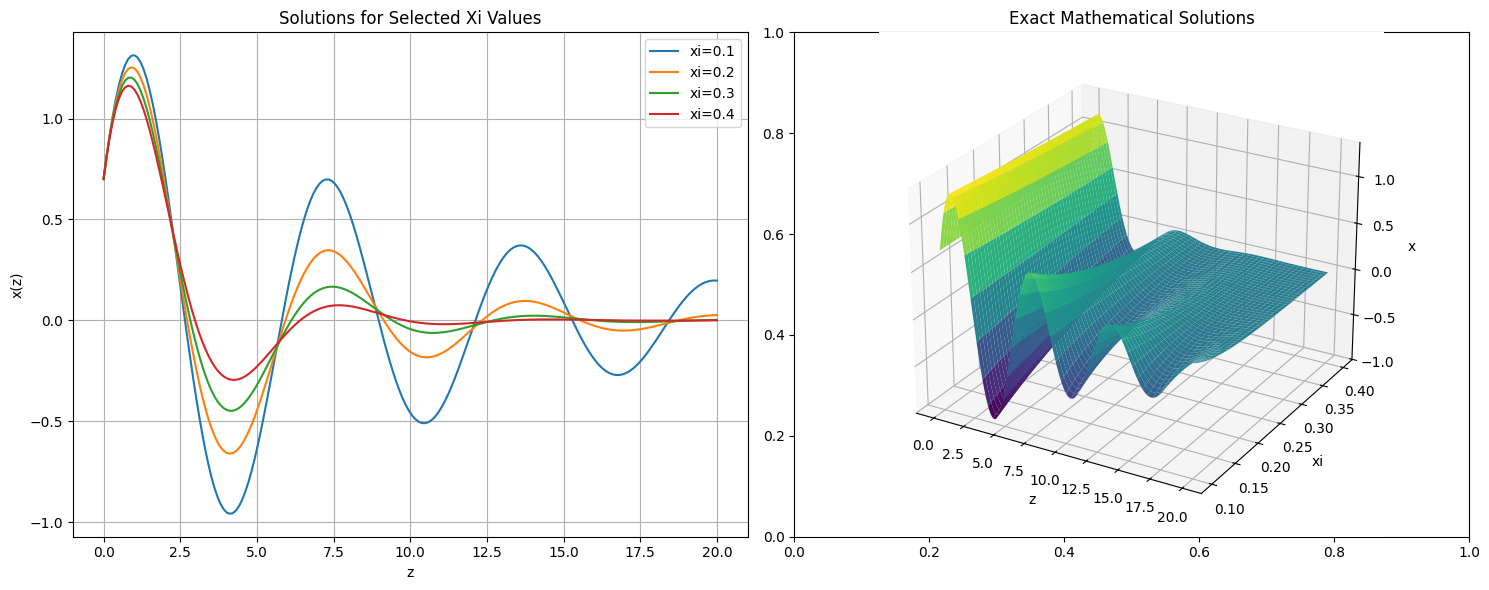

In [3]:
z = np.linspace(0, 20, 200)
xi = np.linspace(0.1, 0.4, 200)
Z, XI = np.meshgrid(z, xi)
omega = np.sqrt(1 - XI**2)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
xi_vals = [0.1, 0.2, 0.3, 0.4]

# plot of the mathematical solutions with selected xi values
for xi_val in xi_vals:
    x = exact_solution(z, xi_val)
    axes[0].plot(z, x, label=f"xi={xi_val}")

axes[0].set_xlabel("z")
axes[0].set_ylabel("x(z)")
axes[0].set_title('Solutions for Selected Xi Values')
axes[0].legend()
axes[0].grid(True)

# mathematical solutions for 3D plot
X = exact_solution(Z, XI)

# create 3D plot
ax_3d = fig.add_subplot(1, 2, 2, projection='3d')
ax_3d.plot_surface(Z, XI, X, cmap='viridis')
ax_3d.set_xlabel('z')
ax_3d.set_ylabel('xi')
ax_3d.set_zlabel('x')
ax_3d.set_title('Exact Mathematical Solutions')
ax_3d.view_init(elev=25, azim=-60)
ax_3d.grid(True)
plt.tight_layout()
plt.show()

## 3. Implementations of the PINN Method


In order to better implement the PINN method, we normalize the range of $z$ into $[0,1]$. Replace $z$ with $\frac{z}{20}$,
$$\frac{d^2x}{dz^2}+2\xi \frac{dx}{dz}+x =0 \implies \frac{d^2x}{dz^2}+40\xi \frac{dx}{dz}+400x =0.$$

Normalizing the range of $z$ keeps the inputs in a small, consistent range, which makes it easier for the neural network to learn the solution. It also leads to smoother behavior and more stable gradients calculations, so training becomes faster and more reliable.


In [4]:
# check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available. Training on GPU.")
else:
    device = torch.device("cpu")
    print("GPU is not available. Training on CPU.")

GPU is available. Training on GPU.


In [5]:
def set_seed(seed=42):
    '''
    Seeding the random variables for reproducibility
    '''
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

In [6]:
class PINN(nn.Module):
    """
    PINN class for solving differential equations.
    """
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, z, xi):
        """
        Performs the forward pass of the PINN.
        """
        inputs = torch.cat([z, xi], dim=1)
        return self.net(inputs)

In [7]:
def residual(model, z, xi):
    """
    Computes the residual of the normalized ODE: d^2x/dz^2 + 40*xi*dx/dz + 400*x = 0.
    """
    z.requires_grad_(True)
    x = model(z, xi)
    dx = autograd.grad(x, z, torch.ones_like(x), create_graph=True)[0]
    d2x = autograd.grad(dx, z, torch.ones_like(dx), create_graph=True)[0]
    residual = d2x + 40 * xi * dx + 400 * x
    return residual

The training of this Physics-informed Neural Network (PINN) is formulated as the minization of a composite loss function:
$$\mathcal{L} = \mathcal{L}_{\text{interior}} + \text{weight} \cdot \mathcal{L}_{\text{boundary}}$$
The weight factor here specificall amplifies the importance of correctly satisfying the boundary conditions (one Dirichlet type and one Neumann type) at $z=0$. The optimizer then performs gradient descent updates on the network parameters to minimize this total loss $\mathcal{L}$.

Epoch 0, Loss: 3275.7502441406
Epoch 1000, Loss: 543.0601806641
Epoch 2000, Loss: 348.2074584961
Epoch 3000, Loss: 192.3678131104
Epoch 4000, Loss: 143.8438110352
Epoch 5000, Loss: 100.7850112915
Epoch 6000, Loss: 87.0586547852
Epoch 7000, Loss: 63.2555236816
Epoch 8000, Loss: 62.0581130981
Epoch 9000, Loss: 65.0666046143
Epoch 10000, Loss: 45.6290588379
Epoch 11000, Loss: 78.0991821289
Epoch 12000, Loss: 37.4331359863
Epoch 13000, Loss: 346.1144409180
Epoch 14000, Loss: 62.7765998840
Epoch 15000, Loss: 49.1994476318
Epoch 16000, Loss: 45.9327697754
Epoch 17000, Loss: 32.8387298584
Epoch 18000, Loss: 33.2400817871
Epoch 19000, Loss: 32.9758377075
Epoch 20000, Loss: 47.7617530823
Epoch 21000, Loss: 24.2736282349
Epoch 22000, Loss: 79.3472213745
Epoch 23000, Loss: 24.0044593811
Epoch 24000, Loss: 16.6084632874
Epoch 25000, Loss: 22.9765815735
Epoch 26000, Loss: 18.2895908356
Epoch 27000, Loss: 17.8775653839
Epoch 28000, Loss: 14.0179452896
Epoch 29000, Loss: 13.5561504364
Epoch 30000, Lo

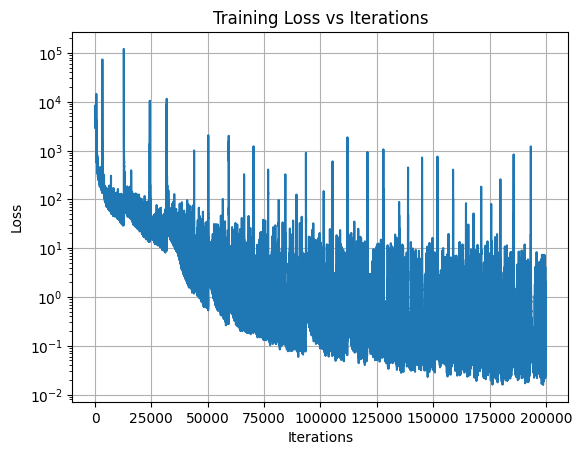

In [10]:
set_seed(42)
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-7)
loss_history = []
x0 = 0.7
v0 = 1.2

epochs = 200000
collocation = 1000
weight = 5

for epoch in range(epochs):
    z = torch.rand(collocation, 1).to(device)
    xi = 0.1 + 0.3 * torch.rand(collocation, 1).to(device)
    res = residual(model, z, xi)
    loss_pde = torch.mean(res**2)
    xi_bc = 0.1 + 0.3 * torch.rand(200, 1).to(device)
    z0_tensor = torch.zeros_like(xi_bc).to(device)
    z0_tensor.requires_grad_(True)
    x_pred = model(z0_tensor, xi_bc)
    dx_pred = autograd.grad(
        x_pred, z0_tensor, torch.ones_like(x_pred), create_graph=True
    )[0]
    # boundary condition v0 is adjusted by rescaling
    loss_bc = torch.mean((x_pred - x0)**2) + torch.mean((dx_pred - 20 * v0)**2)
    # PINN loss function
    loss = loss_pde + weight * loss_bc
    loss_history.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.10f}")

plt.figure()
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss vs Iterations")
plt.yscale('log')
plt.grid(True)
plt.show()

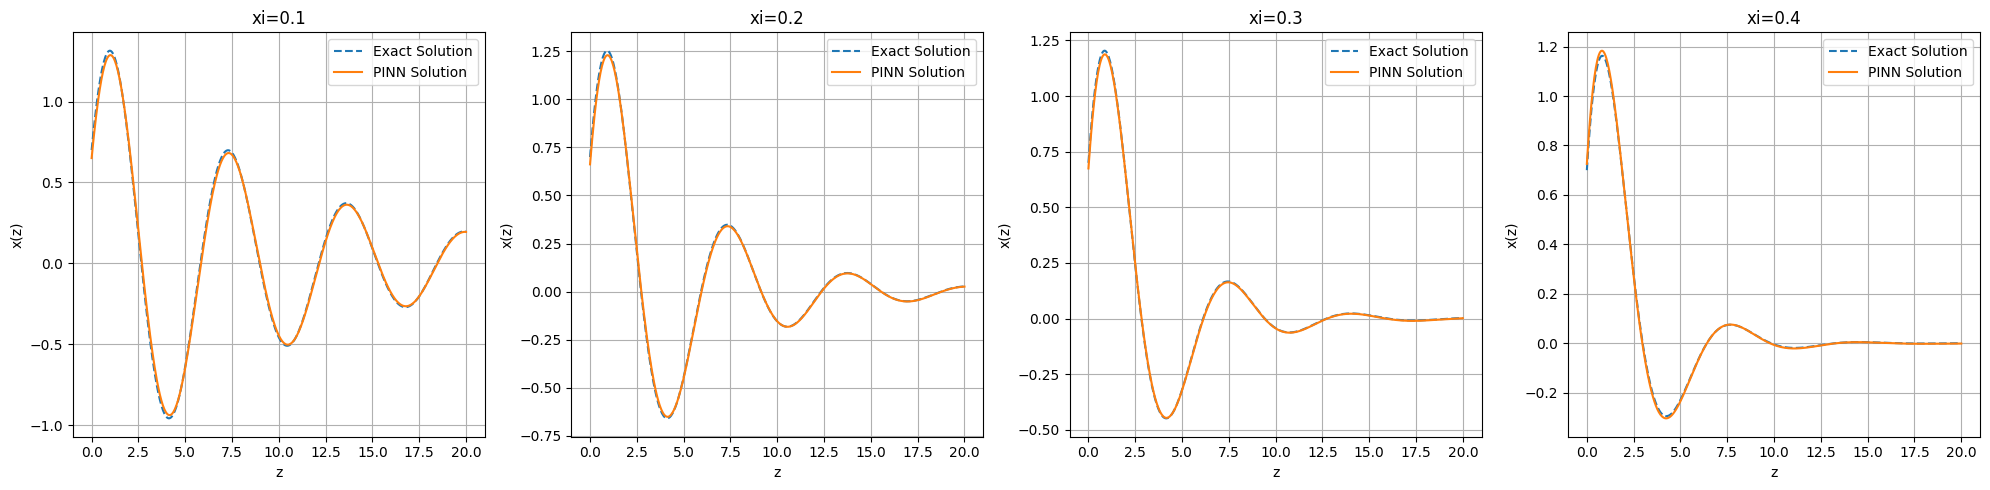

In [11]:
model.eval()
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

z_np = np.linspace(0, 20, 500)
z_torch = torch.tensor(z_np, dtype=torch.float32).view(-1, 1).to(device) / 20
for i, xi_val in enumerate(xi_vals):
    ax = axes[i]
    xi_torch = torch.full_like(z_torch, xi_val).to(device)
    with torch.no_grad():
        x_pinn = model(z_torch, xi_torch).cpu().numpy()
    x_exact = exact_solution(z_np, xi_val)
    ax.plot(z_np, x_exact, '--', label='Exact Solution')
    ax.plot(z_np, x_pinn.flatten(), label='PINN Solution')
    ax.set_xlabel("z")
    ax.set_ylabel("x(z)")
    ax.set_title(f'xi={xi_val}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

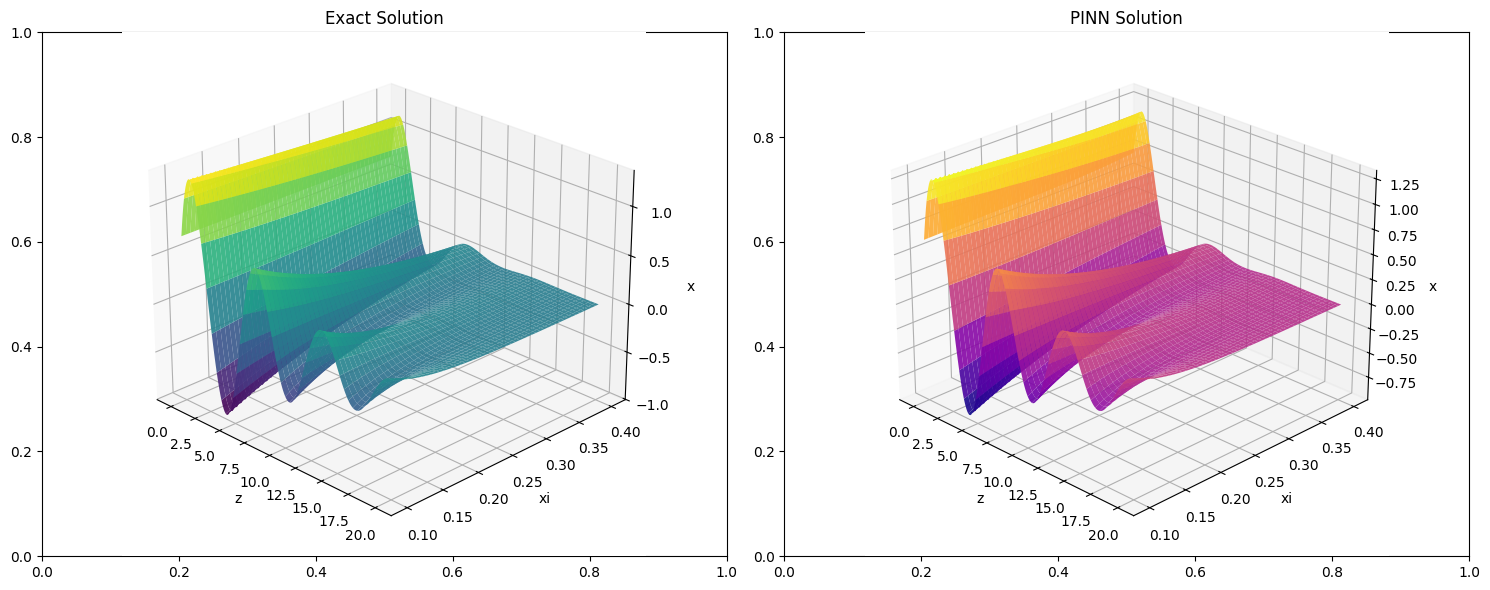

In [12]:
z_torch = torch.tensor(Z.flatten(), dtype=torch.float32).view(-1,1).to(device) / 20
xi_torch = torch.tensor(XI.flatten(), dtype=torch.float32).view(-1,1).to(device)
with torch.no_grad():
    X_pinn = model(z_torch, xi_torch).cpu().numpy()
X_pinn = X_pinn.reshape(Z.shape)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# exact solution
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(Z, XI, X, cmap='viridis', alpha=0.9)
ax1.set_title('Exact Solution')
ax1.set_xlabel('z')
ax1.set_ylabel('xi')
ax1.set_zlabel('x')
ax1.view_init(elev=25, azim=-45)

# PINN solution
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(Z, XI, X_pinn, cmap='plasma', alpha=0.9)
ax2.set_title('PINN Solution')
ax2.set_xlabel('z')
ax2.set_ylabel('xi')
ax2.set_zlabel('x')
ax2.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.show()

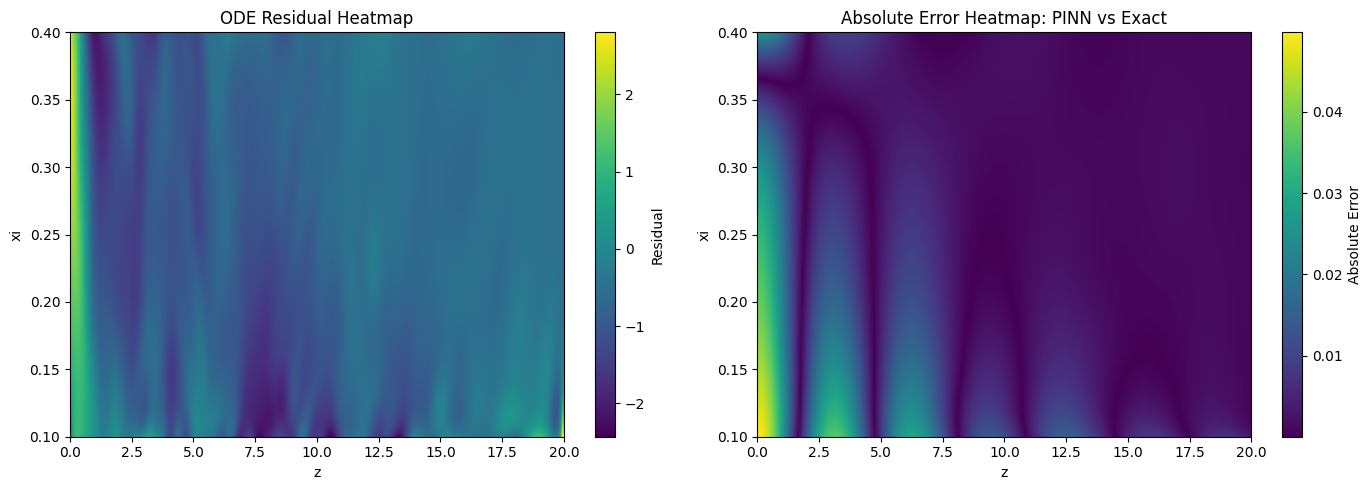

Max Norm Error: 0.049788
Mean Square Error: 0.000086


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ODE Residual Heatmap
res = residual(model, z_torch, xi_torch).detach().cpu().numpy()
res = res.reshape(Z.shape)

im1 = axes[0].imshow(res, extent=[0, 20, 0.1, 0.4], aspect='auto', origin='lower')
plt.colorbar(im1, ax=axes[0], label="Residual")
axes[0].set_xlabel("z")
axes[0].set_ylabel("xi")
axes[0].set_title("ODE Residual Heatmap")

# absolute error heatmap
error = np.abs(X_pinn - X)

im2 = axes[1].imshow(error, extent=[0, 20, 0.1, 0.4], aspect='auto', origin='lower')
plt.colorbar(im2, ax=axes[1], label="Absolute Error")
axes[1].set_xlabel("z")
axes[1].set_ylabel("xi")
axes[1].set_title("Absolute Error Heatmap: PINN vs Exact")

plt.tight_layout()
plt.show()

# calculate the max-norm error
max_norm_error = np.max(np.abs(X_pinn - X))
print(f"Max Norm Error: {max_norm_error:.6f}")

# calculate the mean square error
mse = np.mean((X_pinn - X)**2)
print(f"Mean Square Error: {mse:.6f}")

## 4. Improvements of the PINN Method

With these hyperparameters designated for the training process (e.g. epoch=200000, colloaction=1000), the result of this model displays noticeable errors, especially when $z=0$ (loose boundary condition enforcement) and when $\xi$ is small (more oscillations). These issues are typical in standard PINNs: the neural network must simultaneously learn both the governing differential equation and the boundary/initial conditions, which can lead to multiple optimization objectives and slow convergence near constrained regions. Two specific improvements are proposed to alleviate these errors.

*   Hard Constraint Enforcement: Instead of enforcing initial conditions through an additional penalty term in the loss function, we can explicitly embed them into the solution ansatz. With this modification, the network wil always learn a correction term added to a function that already satisfies the initial conditions exactly. The hard constraint enforces the solution as:
$$x(z, \xi)=x_0 + (20 v_0)z + z^2 \mathcal{N}_{\theta}(z, \xi)$$
where $\mathcal{N}_{\theta}$ is the neural network output. ($20v_0$ here because of rescaling)
*   Fourier Feature Embedding: A second limitation of standard PINNs is their difficulty in learning high-frequency or oscillatory solutions, particularly when the damping ratio $\xi$ is small and the system exhibits rapid oscillations. To address this, we apply the Fourier feature mappings to the input variables before passing them into the neural network. Specifically, the inputs $(z, \xi)$ are mapped into a higher-dimensional periodic representation:
$$(z, \xi) ↦ (\sin(2\pi B(z,\xi)), \cos(2\pi B(z,\xi)))$$
where $B$ is a fixed random projection matrix.



In [6]:
class FourierFeatures(nn.Module):
    '''
    Class for implementing fourier features
    '''
    def __init__(self, in_dim, num_features=64, scale=4.0):
        super().__init__()
        self.B = nn.Parameter(
            torch.randn(in_dim, num_features) * scale,
            requires_grad=False
        )

    def forward(self, x):
        proj = 2 * np.pi * x @ self.B
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

In [7]:
class PINN_Modified(nn.Module):
    def __init__(self):
        super(PINN_Modified, self).__init__()
        self.x0 = 0.7
        self.v0 = 1.2
        self.embedding = FourierFeatures(in_dim=2, num_features=64, scale=4.0)
        self.net = nn.Sequential(
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.01)
                nn.init.zeros_(m.bias)

    def forward(self, z, xi):
        inputs = torch.cat([z, xi], dim=1)
        embedded = self.embedding(inputs)
        N = self.net(embedded)
        return self.x0 + (20 * self.v0) * z + z**2 * N

In [8]:
def residual_modified(model, z, xi):
    z = z.detach().requires_grad_(True)
    x = model(z, xi)
    dx = torch.autograd.grad(x, z, torch.ones_like(x), create_graph=True)[0]
    d2x = torch.autograd.grad(dx, z, torch.ones_like(dx), create_graph=True)[0]
    return d2x + 40 * xi * dx + 400 * x

Epoch 0, Loss: 36034792.0000000000, LR: 1.00e-03
Epoch 1000, Loss: 1046886.3125000000, LR: 1.00e-03
Epoch 2000, Loss: 313656.6875000000, LR: 1.00e-03
Epoch 3000, Loss: 68050.4062500000, LR: 1.00e-03
Epoch 4000, Loss: 33316.6054687500, LR: 1.00e-03
Epoch 5000, Loss: 20441.6347656250, LR: 1.00e-03
Epoch 6000, Loss: 11500.0546875000, LR: 1.00e-03
Epoch 7000, Loss: 11452.8095703125, LR: 1.00e-03
Epoch 8000, Loss: 8658.0244140625, LR: 1.00e-03
Epoch 9000, Loss: 7088.3066406250, LR: 1.00e-03
Epoch 10000, Loss: 4673.1943359375, LR: 1.00e-03
Epoch 11000, Loss: 3416.3718261719, LR: 1.00e-03
Epoch 12000, Loss: 2712.5065917969, LR: 1.00e-03
Epoch 13000, Loss: 2341.3166503906, LR: 1.00e-03
Epoch 14000, Loss: 2074.7287597656, LR: 1.00e-03
Epoch 15000, Loss: 2040.9398193359, LR: 1.00e-03
Epoch 16000, Loss: 1581.9932861328, LR: 1.00e-03
Epoch 17000, Loss: 1372.3167724609, LR: 1.00e-03
Epoch 18000, Loss: 1170.5302734375, LR: 1.00e-03
Epoch 19000, Loss: 942.1128540039, LR: 1.00e-03
Epoch 20000, Loss: 8

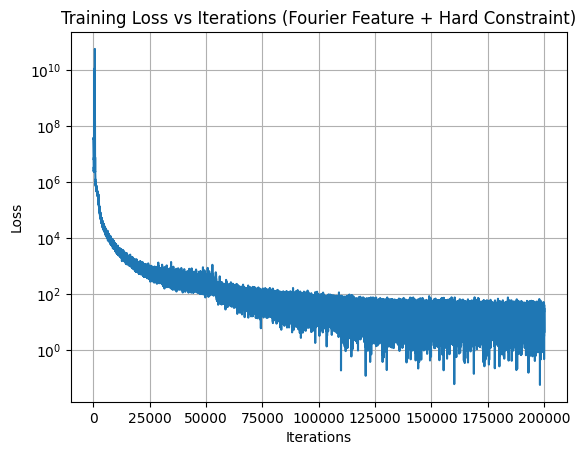

In [15]:
set_seed(42)
model2 = PINN_Modified().to(device)
optimizer = torch.optim.AdamW(model2.parameters(), lr=1e-3, weight_decay=1e-4)
# design that scheduler that updates appropriate learning rates adaptively
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5000, min_lr=1e-6
)

epochs = 200000
collocation = 1000
loss_history = []
best_loss = float('inf')

for epoch in range(epochs):
    z = torch.rand(collocation, 1).to(device)
    xi = 0.1 + 0.3 * torch.rand(collocation, 1).to(device)
    res = residual_modified(model2, z, xi)
    loss = torch.mean(res**2)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model2.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step(loss.item())
    loss_history.append(loss.item())

    if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save({'model_state_dict': model2.state_dict()}, 'best_pinn_modified.pth')

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.10f}, LR: {optimizer.param_groups[0]['lr']:.2e}")

checkpoint = torch.load('best_pinn_modified.pth')
model2.load_state_dict(checkpoint['model_state_dict'])
print(f"Best loss: {best_loss:.10f}")

plt.figure()
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss vs Iterations (Fourier Feature + Hard Constraint)")
plt.yscale('log')
plt.grid(True)
plt.show()

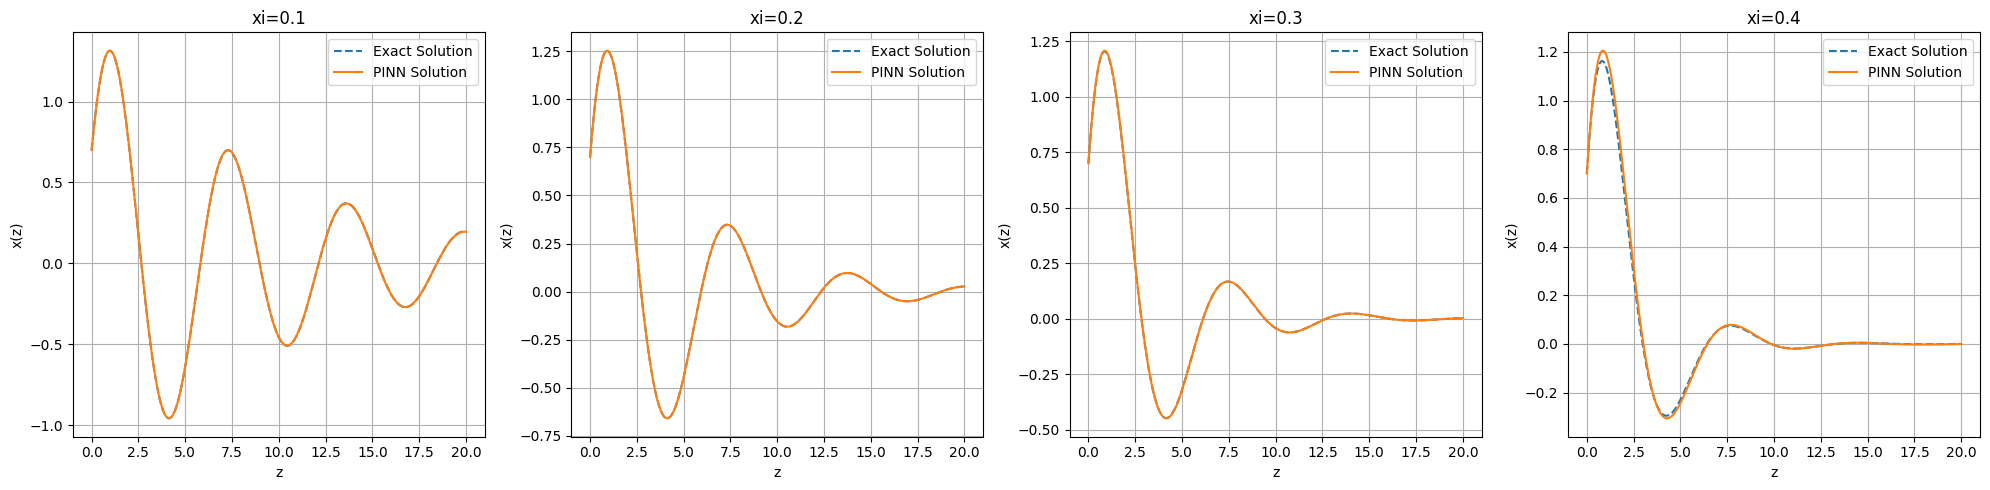

In [16]:
model2.eval()
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

z_np = np.linspace(0, 20, 500)
z_torch = torch.tensor(z_np, dtype=torch.float32).view(-1, 1).to(device) / 20
for i, xi_val in enumerate(xi_vals):
    ax = axes[i]
    xi_torch = torch.full_like(z_torch, xi_val).to(device)
    with torch.no_grad():
        x_pinn = model2(z_torch, xi_torch).cpu().numpy()
    x_exact = exact_solution(z_np, xi_val)
    ax.plot(z_np, x_exact, '--', label='Exact Solution')
    ax.plot(z_np, x_pinn.flatten(), label='PINN Solution')
    ax.set_xlabel("z")
    ax.set_ylabel("x(z)")
    ax.set_title(f'xi={xi_val}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

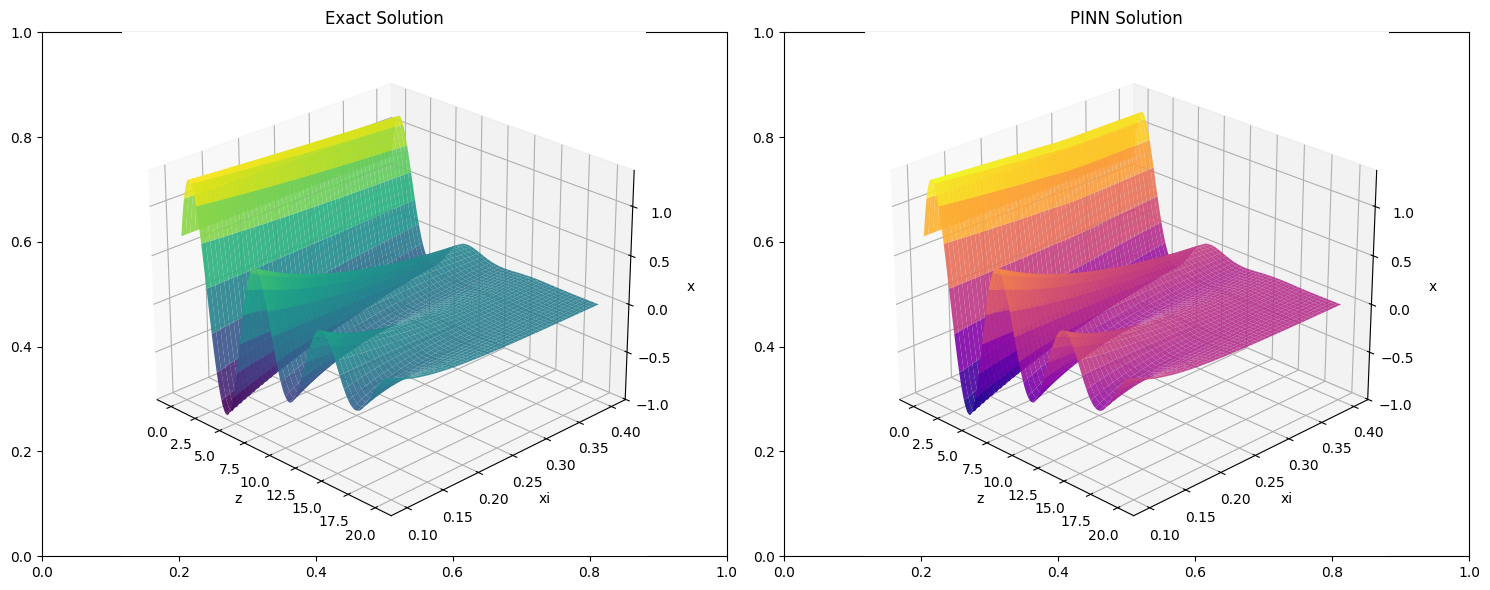

In [17]:
z_torch = torch.tensor(Z.flatten(), dtype=torch.float32).view(-1,1).to(device) / 20
xi_torch = torch.tensor(XI.flatten(), dtype=torch.float32).view(-1,1).to(device)
with torch.no_grad():
    X_pinn = model2(z_torch, xi_torch).cpu().numpy()
X_pinn = X_pinn.reshape(Z.shape)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# exact solution
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(Z, XI, X, cmap='viridis', alpha=0.9)
ax1.set_title('Exact Solution')
ax1.set_xlabel('z')
ax1.set_ylabel('xi')
ax1.set_zlabel('x')
ax1.view_init(elev=25, azim=-45)

# PINN solution
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(Z, XI, X_pinn, cmap='plasma', alpha=0.9)
ax2.set_title('PINN Solution')
ax2.set_xlabel('z')
ax2.set_ylabel('xi')
ax2.set_zlabel('x')
ax2.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.show()

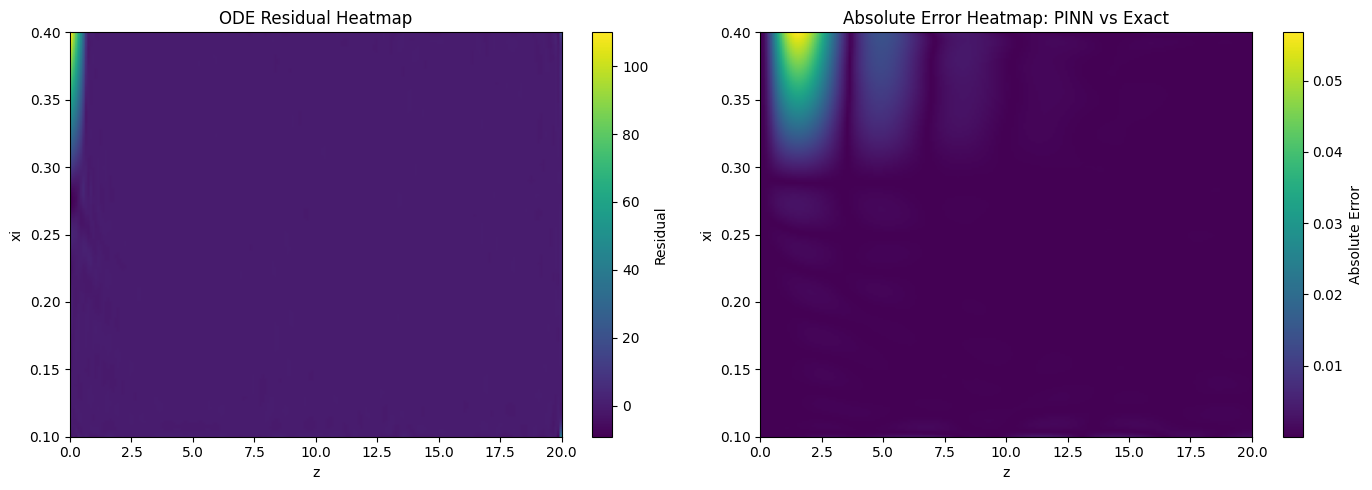

Max Norm Error: 0.056807
Mean Square Error: 0.000035


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ODE Residual Heatmap
res = residual_modified(model2, z_torch, xi_torch).detach().cpu().numpy()
res = res.reshape(Z.shape)

im1 = axes[0].imshow(res, extent=[0, 20, 0.1, 0.4], aspect='auto', origin='lower')
plt.colorbar(im1, ax=axes[0], label="Residual")
axes[0].set_xlabel("z")
axes[0].set_ylabel("xi")
axes[0].set_title("ODE Residual Heatmap")

# absolute error heatmap
error = np.abs(X_pinn - X)

im2 = axes[1].imshow(error, extent=[0, 20, 0.1, 0.4], aspect='auto', origin='lower')
plt.colorbar(im2, ax=axes[1], label="Absolute Error")
axes[1].set_xlabel("z")
axes[1].set_ylabel("xi")
axes[1].set_title("Absolute Error Heatmap: PINN vs Exact")

plt.tight_layout()
plt.show()

# calculate the max-norm error
max_norm_error = np.max(np.abs(X_pinn - X))
print(f"Max Norm Error: {max_norm_error:.6f}")

# calculate the mean square error
mse = np.mean((X_pinn - X)**2)
print(f"Mean Square Error: {mse:.6f}")